### Data Loading

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/kaggle/input/insurance/insurance.csv")

print("Dataset loaded successfully!")

# 1. Display the first 5 rows
print("===== HEAD OF DATASET =====")
print(df.head())

# 2. Display dataset shape
print("\n===== DATASET SHAPE =====")
print("Rows and Columns:", df.shape)

# 3. Display column names
print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

# 4. Display dataset information
print("\n===== DATASET INFORMATION =====")
df.info()

# 5. Display statistical summary
print("\n===== STATISTICAL SUMMARY =====")
print(df.describe())

Dataset loaded successfully!
===== HEAD OF DATASET =====
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

===== DATASET SHAPE =====
Rows and Columns: (1338, 7)

===== COLUMN NAMES =====
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

===== DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 

### Data Cleaning & Preprocessing

In [ ]:

# -----------------------------
# 1. Check Missing Values
# -----------------------------
print("===== MISSING VALUES =====")
print(df.isnull().sum())

# -----------------------------
# 2. Check Duplicate Records
# -----------------------------
print("\n===== DUPLICATES =====")
print("Duplicate records:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# -----------------------------
# 3. Check Data Types
# -----------------------------
print("\n===== DATA TYPES =====")
print(df.dtypes)

# -----------------------------
# 4. Identify Categorical Variables
# -----------------------------
categorical_columns = df.select_dtypes(
    include=['object']
).columns

print("\n===== CATEGORICAL VARIABLES =====")
print(categorical_columns.tolist())

# -----------------------------
# 5. Display Categories
# -----------------------------
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())

# -----------------------------
# 6. Convert Categorical Data
#    into Numerical Form
# -----------------------------
df_encoded = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True,
    dtype=int
)

# -----------------------------
# 7. Verify Cleaned Dataset
# -----------------------------
print("\n===== CLEANED DATASET =====")
display(df_encoded.head())

print("\n===== FINAL SHAPE =====")
print(df_encoded.shape)

print("\n===== FINAL DATA TYPES =====")
print(df_encoded.dtypes)

print("\n===== TOTAL MISSING VALUES =====")
print(df_encoded.isnull().sum().sum())

===== MISSING VALUES =====
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

===== DUPLICATES =====
Duplicate records: 1

===== DATA TYPES =====
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

===== CATEGORICAL VARIABLES =====
['sex', 'smoker', 'region']

sex:
['female' 'male']

smoker:
['yes' 'no']

region:
['southwest' 'southeast' 'northwest' 'northeast']

===== CLEANED DATASET =====


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0



===== FINAL SHAPE =====
(1337, 9)

===== FINAL DATA TYPES =====
age                   int64
bmi                 float64
children              int64
charges             float64
sex_male              int64
smoker_yes            int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

===== TOTAL MISSING VALUES =====
0


### Exploratory Data Analysis

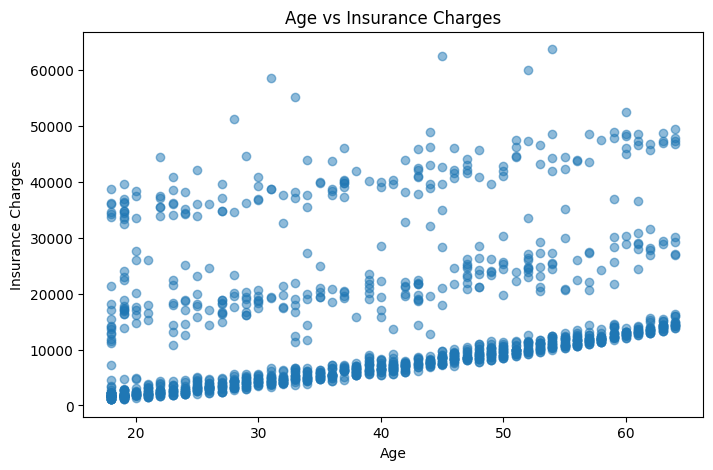

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df['age'], df['charges'], alpha=0.5)

plt.xlabel('Age')
plt.ylabel('Insurance Charges')
plt.title('Age vs Insurance Charges')

plt.show()

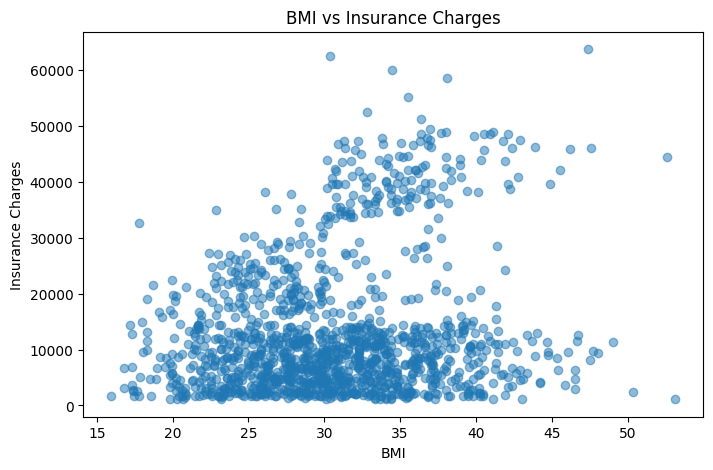

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df['bmi'], df['charges'], alpha=0.5)

plt.xlabel('BMI')
plt.ylabel('Insurance Charges')
plt.title('BMI vs Insurance Charges')

plt.show()

<Figure size 800x500 with 0 Axes>

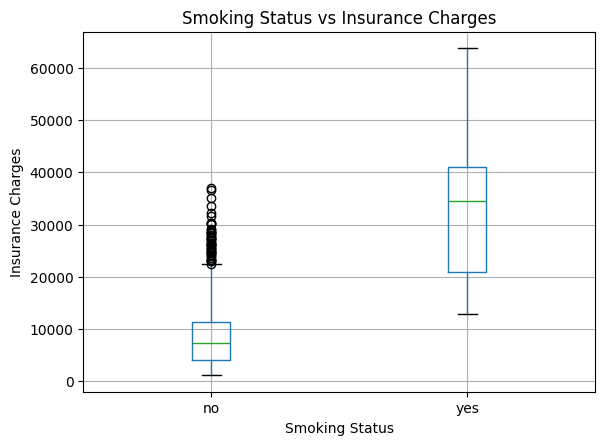

In [ ]:
plt.figure(figsize=(8, 5))

df.boxplot(column='charges', by='smoker')

plt.xlabel('Smoking Status')
plt.ylabel('Insurance Charges')
plt.title('Smoking Status vs Insurance Charges')

plt.suptitle('')

plt.show()

In [ ]:
print(df[['age', 'bmi', 'charges']].corr())

              age       bmi   charges
age      1.000000  0.109344  0.298308
bmi      0.109344  1.000000  0.198401
charges  0.298308  0.198401  1.000000


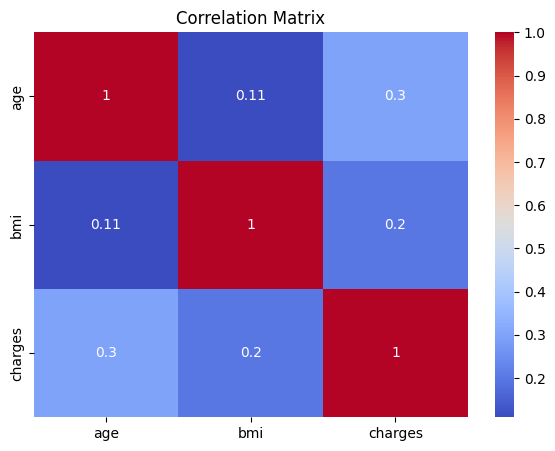

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.heatmap(
    df[['age', 'bmi', 'charges']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Calculate average insurance charges for smokers and non-smokers

average_charges = df.groupby('smoker')['charges'].mean()

print("Average Insurance Charges:")
print(average_charges)

print("Average charges for non-smokers:",
      df[df['smoker'] == 'no']['charges'].mean())

print("Average charges for smokers:",
      df[df['smoker'] == 'yes']['charges'].mean())

Average Insurance Charges:
smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64
Average charges for non-smokers: 8440.660306508937
Average charges for smokers: 32050.23183153284


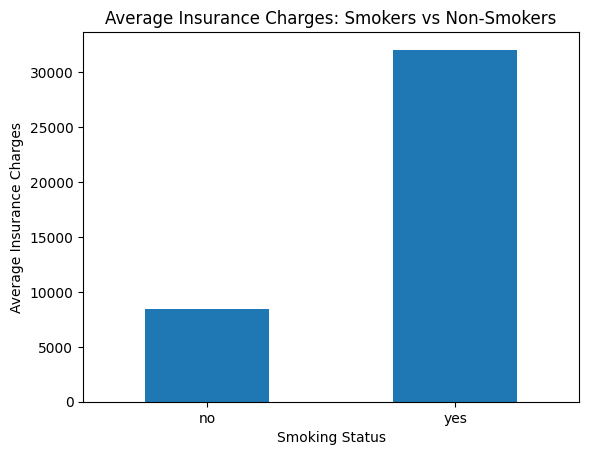

In [ ]:
import matplotlib.pyplot as plt

average_charges.plot(kind='bar')

plt.xlabel('Smoking Status')
plt.ylabel('Average Insurance Charges')
plt.title('Average Insurance Charges: Smokers vs Non-Smokers')
plt.xticks(rotation=0)

plt.show()

### Separate Features and Target

In [ ]:
# Separate features and target variable

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0         0           1                 0   
1   18  33.770         1         1           0                 0   
2   28  33.000         3         1           0                 0   
3   33  22.705         0         1           0                 1   
4   32  28.880         0         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  

Target (y):
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


### Split Data into Training and Testing Sets


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1069, 8)
Testing data: (268, 8)


### Train  Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Display dataset sizes
print("Total records:", len(df_encoded))
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\n Linear Regression model trained successfully!")

Total records: 1337
Training records: 1069
Testing records: 268

 Linear Regression model trained successfully!


### Sample Predictions

In [ ]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Actual Charges': y_test.values[:10],
    'Predicted Charges': y_pred[:10]
})

display(results)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


### Calculate R² and RMSE

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

R² Score: 0.8069
RMSE: 4646.06
MAE: 4177.05


### Using polynomial Features

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

r2 = r2_score(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_poly)

print("R²:", r2)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.8825298972468527
MSE: 21585843.724421863
RMSE: 4646.05679306892
MAE: 2867.317439475318


In [ ]:

results = pd.DataFrame({
    'Actual Charges': y_test.values[:10],
    'Predicted Charges': y_pred_poly[:10]
})

display(results)

,Actual Charges,Predicted Charges
0,8688.85885,8353.843089
1,5708.86700,6542.119190
2,11436.73815,14316.736746
3,38746.35510,35908.934065
4,4463.20510,5652.797364
5,9304.70190,11043.960730
6,38511.62830,41404.599387
7,2150.46900,3085.076248
8,7345.72660,8734.844723
9,10264.44210,12346.930950


### Trying Random forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("R²:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R²: 0.8815859348971048
MSE: 21759302.530414518
RMSE: 4664.686755872737


In [ ]:
import joblib

joblib.dump(poly, "/content/polynomial_features.pkl")
joblib.dump(model_poly, "/content/insurance_model.pkl")

print("Models saved successfully!")

Models saved successfully!


In [ ]:
import gradio as gr
import pandas as pd

# Prediction function
def predict_insurance(age, bmi, children, gender, smoker, region):

    input_data = pd.DataFrame({
        "age": [age],
        "bmi": [bmi],
        "children": [children],
        "sex_male": [1 if gender == "male" else 0],
        "smoker_yes": [1 if smoker == "yes" else 0],
        "region_northwest": [1 if region == "northwest" else 0],
        "region_southeast": [1 if region == "southeast" else 0],
        "region_southwest": [1 if region == "southwest" else 0]
    })

    input_poly = poly.transform(input_data)

    prediction = model_poly.predict(input_poly)[0]

    return f"${prediction:,.2f}"


# Modern dark UI
custom_css = """

/* Main background */
body {
    background: #0b1220 !important;
}

.gradio-container {
    max-width: 1000px !important;
    margin: auto !important;
    background: #0b1220 !important;
}

/* Header */
.header {
    text-align: center;
    padding: 30px 10px 20px 10px;
}

.title {
    font-size: 38px;
    font-weight: 800;
    color: #ffffff;
}

.subtitle {
    color: #94a3b8;
    font-size: 16px;
    margin-top: 8px;
}

/* Cards */
.card {
    background: #111c2e !important;
    border: 1px solid #24344d !important;
    border-radius: 18px !important;
    padding: 25px !important;
    box-shadow: 0 10px 30px rgba(0,0,0,0.25);
}

/* Section headings */
.section-title {
    color: #60a5fa;
    font-size: 20px;
    font-weight: 700;
    margin-bottom: 15px;
}

/* Labels */
label {
    color: #cbd5e1 !important;
}

/* Input fields */
input,
textarea,
button,
select {
    border-radius: 10px !important;
}

/* Result */
.result {
    text-align: center;
    font-size: 30px !important;
    font-weight: 800 !important;
    color: #60a5fa !important;
}

/* Prediction button */
.predict-btn {
    margin-top: 15px;
}

/* Model info */
.model-info {
    background: #0f1a2b;
    border-radius: 12px;
    padding: 18px;
    border: 1px solid #24344d;
    color: #cbd5e1;
}

/* Footer */
.footer {
    text-align: center;
    color: #64748b;
    margin-top: 25px;
    font-size: 13px;
}

"""


with gr.Blocks(
    css=custom_css,
    theme=gr.themes.Base(
        primary_hue="blue",
        neutral_hue="slate"
    )
) as app:

    # Header
    gr.HTML("""
    <div class="header">
        <div class="title">
            🏥 Medical Insurance Predictor
        </div>

        <div class="subtitle">
            Machine Learning powered insurance cost estimation
        </div>
    </div>
    """)

    with gr.Row():

        # =========================
        # LEFT CARD
        # =========================

        with gr.Column(
            scale=1,
            elem_classes="card"
        ):

            gr.HTML("""
            <div class="section-title">
                👤 Patient Information
            </div>
            """)

            age = gr.Slider(
                minimum=18,
                maximum=100,
                value=30,
                step=1,
                label="Age"
            )

            bmi = gr.Slider(
                minimum=10,
                maximum=60,
                value=25,
                step=0.1,
                label="BMI"
            )

            children = gr.Slider(
                minimum=0,
                maximum=10,
                value=0,
                step=1,
                label="Number of Children"
            )

            gender = gr.Radio(
                ["male", "female"],
                value="male",
                label="Gender"
            )

            smoker = gr.Radio(
                ["yes", "no"],
                value="no",
                label="Smoking Status"
            )

            region = gr.Dropdown(
                [
                    "northeast",
                    "northwest",
                    "southeast",
                    "southwest"
                ],
                value="northeast",
                label="Region"
            )

            predict_btn = gr.Button(
                "🔮  Predict Insurance Cost",
                variant="primary",
                size="lg",
                elem_classes="predict-btn"
            )


        # =========================
        # RIGHT CARD
        # =========================

        with gr.Column(
            scale=1,
            elem_classes="card"
        ):

            gr.HTML("""
            <div class="section-title">
                💰 Prediction
            </div>
            """)

            result = gr.Textbox(
                label="Estimated Insurance Cost",
                placeholder="Enter patient information and click Predict",
                elem_classes="result",
                interactive=False
            )

            gr.Markdown("### 📊 Model Performance")

            gr.HTML("""
            <div class="model-info">

            <b>Polynomial Regression (Degree 2)</b>

            <br><br>

            <b>R² Score</b><br>
            0.8825

            <br><br>

            <b>RMSE</b><br>
            $4,646.06

            <br><br>

            <b>MSE</b><br>
            21,585,843.72

            </div>
            """)

            gr.Markdown("### 🤖 Features Used")

            gr.Markdown("""
            • Age
            • BMI
            • Number of children
            • Gender
            • Smoking status
            • Region
            """)

    # Prediction action
    predict_btn.click(
        fn=predict_insurance,
        inputs=[
            age,
            bmi,
            children,
            gender,
            smoker,
            region
        ],
        outputs=result
    )

    gr.HTML("""
    <div class="footer">
        Medical Insurance Cost Prediction • Machine Learning Project
    </div>
    """)


app.launch(share=True)

/tmp/ipykernel_1032/1765080268.py:120: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://44d6aa92c44758e9d8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from google.colab import files

files.download("/content/insurance_model.pkl")
files.download("/content/polynomial_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>